In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance


In [10]:
df = pd.read_csv(
    "../data/raw/ksp_synthetic_crime_dataset.csv"
)

df.head()

,crime_id,district,police_station,crime_type,date,latitude,longitude,victim_age,offender_age,status,repeat_offender
0,CR000001,Kalaburagi,Kalaburagi PS 4,Vehicle Theft,2023-09-28,17.362084,76.910451,56,36,Closed,0
1,CR000002,Ballari,Ballari PS 5,Assault,2025-05-21,15.110356,76.895142,38,50,Charge Sheet Filed,0
2,CR000003,Tumakuru,Tumakuru PS 1,Cybercrime,2023-02-28,13.314309,77.095126,33,32,Under Investigation,0
3,CR000004,Belagavi,Belagavi PS 4,Robbery,2023-09-01,15.822481,74.503246,68,24,Open,0
4,CR000005,Mysuru,Mysuru PS 4,Theft,2023-11-12,12.194464,76.695371,43,19,Charge Sheet Filed,0


In [11]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

In [12]:
le_district = LabelEncoder()
le_station = LabelEncoder()
le_status = LabelEncoder()
le_repeat = LabelEncoder()
le_target = LabelEncoder()

df['district_enc'] = le_district.fit_transform(df['district'])
df['station_enc'] = le_station.fit_transform(df['police_station'])
df['status_enc'] = le_status.fit_transform(df['status'])
df['repeat_enc'] = le_repeat.fit_transform(df['repeat_offender'])

df['crime_type_enc'] = le_target.fit_transform(
    df['crime_type']
)

In [13]:
X = df[
[
    'district_enc',
    'station_enc',
    'latitude',
    'longitude',
    'victim_age',
    'offender_age',
    'status_enc',
    'repeat_enc',
    'month',
    'weekday'
]
]

y = df['crime_type_enc']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,longitude,0.164123
2,latitude,0.163402
4,victim_age,0.143384
5,offender_age,0.141401
1,station_enc,0.099087
8,month,0.098014
9,weekday,0.084545
6,status_enc,0.061120
7,repeat_enc,0.023613
0,district_enc,0.021311


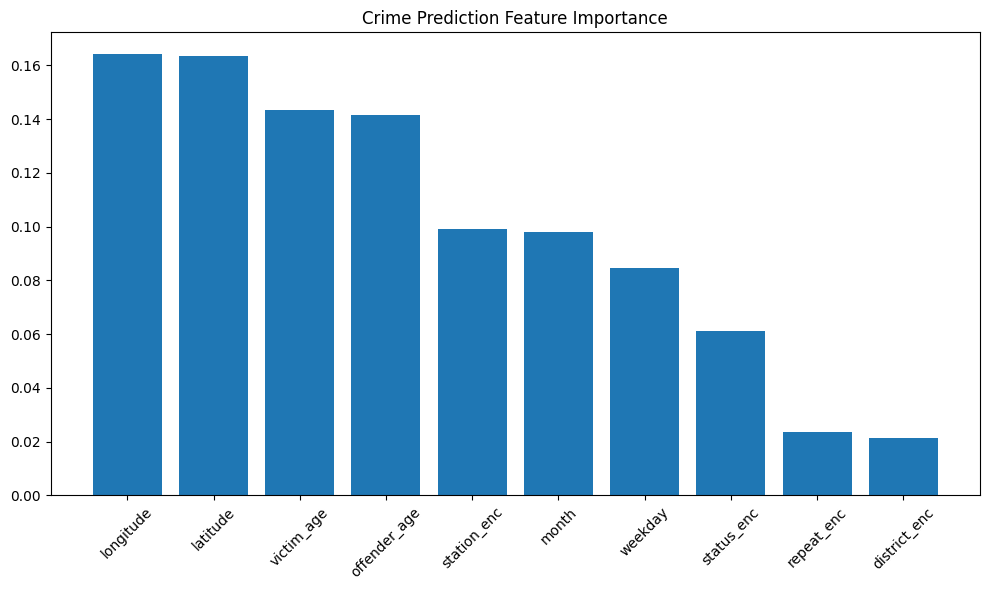

In [16]:
plt.figure(figsize=(10,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title(
    "Crime Prediction Feature Importance"
)

plt.tight_layout()

plt.show()

In [17]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

In [18]:
perm = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

perm = perm.sort_values(
    by='Importance',
    ascending=False
)

perm

,Feature,Importance
4,victim_age,0.0084
6,status_enc,0.0045
2,latitude,0.0036
7,repeat_enc,0.0010
1,station_enc,0.0007
9,weekday,-0.0010
5,offender_age,-0.0020
0,district_enc,-0.0035
8,month,-0.0041
3,longitude,-0.0068


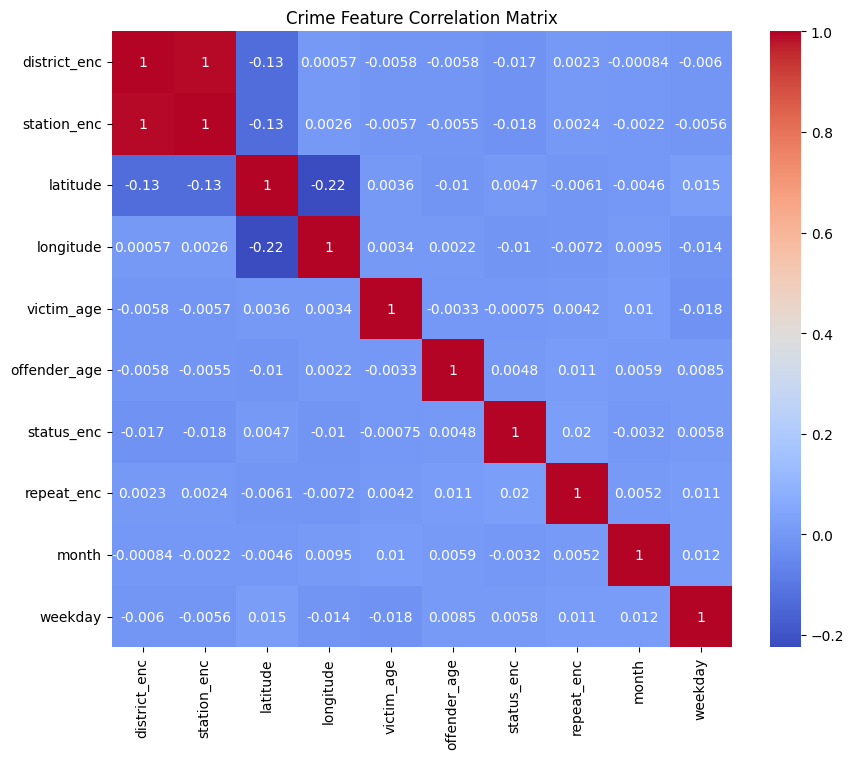

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Crime Feature Correlation Matrix"
)

plt.show()

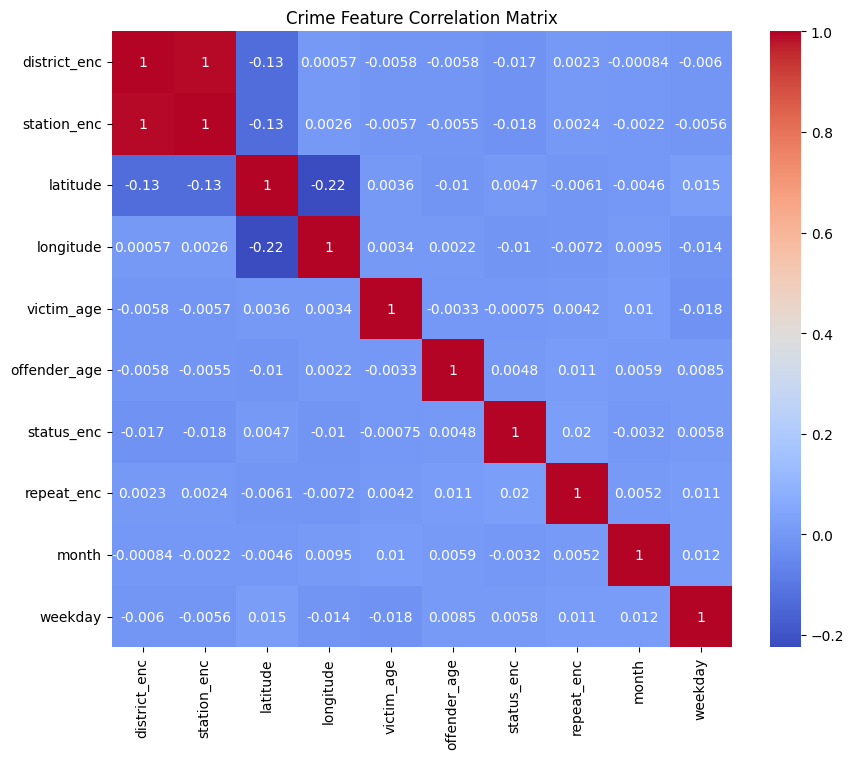

In [20]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Crime Feature Correlation Matrix"
)

plt.show()